# Portfolio optimization — short window (last 3 months, many stocks)

Same long-only mean-variance optimizer as before, but in the $N > T$ regime: last 3 months of daily returns for ~500 stocks. The sample covariance $\Sigma$ is still **singular** ($\mathrm{rank} = T-1 < N$), so the closed-form $\Sigma^{-1}\mu$ is dead — but the softmax optimizer doesn't need the inverse (it only evaluates $w^\top\Sigma w$), so it still runs. The catch: $N > T$ makes the in-sample optimum inflated.


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from stonks import get_prices, to_returns

%matplotlib inline


## Parameters


In [59]:
TOP_N = 500
MONTHS = 3
PERIOD = "2y"      # cached; we slice the last MONTHS from it
INTERVAL = "1d"
gamma = 20.0        # risk aversion


## Fetch, slice last 3 months, compute $\mu$ and $\Sigma$


In [60]:
prices = get_prices(top_n=TOP_N, period=PERIOD, interval=INTERVAL, field="close")
cut = pd.Timestamp(prices.columns[-1]) - pd.DateOffset(months=MONTHS)
returns = to_returns(prices.loc[:, prices.columns >= cut]).dropna()

X = returns.to_numpy(dtype=float)
tickers = list(returns.index)
N, T = X.shape
mu = X.mean(axis=1)
Xc = X - mu[:, None]
Sigma = (Xc @ Xc.T) / (T - 1)
mu_t = torch.tensor(mu, dtype=torch.float64)
Sig_t = torch.tensor(Sigma, dtype=torch.float64)

print(f"N={N} stocks, T={T} days, rank(Sigma)={np.linalg.matrix_rank(Sigma)} (= T-1), cond=%.1e"
      % np.linalg.cond(Sigma))


N=453 stocks, T=63 days, rank(Sigma)=62 (= T-1), cond=1.9e+20


In [55]:
try:
    w_cf = np.linalg.solve(Sigma, mu) / gamma
    print("closed-form 'weights': min=%.3g  max=%.3g  (meaningless - Sigma is singular)"
          % (w_cf.min(), w_cf.max()))
except np.linalg.LinAlgError as e:
    print("closed-form failed:", e)


closed-form 'weights': min=-5.75e+17  max=5.92e+17  (meaningless - Sigma is singular)


## Softmax optimizer (no inverse needed)

$w=\mathrm{softmax}(z)$ keeps $w\ge0$, $\sum w=1$; ascent on $z$ only ever evaluates $w^\top\Sigma w$ (a forward product), so it works even though $\Sigma$ is singular.


In [61]:
z = torch.randn(N, dtype=torch.float64, requires_grad=True)
opt = torch.optim.Adam([z], lr=0.5)
for _ in range(8000):
    opt.zero_grad()
    w = torch.softmax(z, dim=0)
    loss = -(mu_t @ w - 0.5 * gamma * w @ Sig_t @ w)
    loss.backward()
    opt.step()

w_long = torch.softmax(z, dim=0).detach().numpy()
ann_ret = w_long @ mu * 252
ann_vol = np.sqrt(w_long @ Sigma @ w_long) * np.sqrt(252)
print(f"holdings(>1e-3)={int((w_long>1e-3).sum())}  ann_ret={ann_ret*100:.1f}%  vol={ann_vol*100:.1f}%  Sharpe={ann_ret/ann_vol:.2f}")
pd.Series(w_long, index=tickers).sort_values(ascending=False).head(10).round(3)


holdings(>1e-3)=13  ann_ret=220.6%  vol=22.3%  Sharpe=9.87


ELF     0.221
HPE     0.148
SNOW    0.120
DXCM    0.113
MPC     0.086
THC     0.071
EXPE    0.062
GRMN    0.044
VLO     0.037
TRV     0.035
dtype: float64

Text(0.5, 1.0, 'Long-only weights, $\\gamma$=20 ($\\Sigma$ singular, softmax optimizer)')

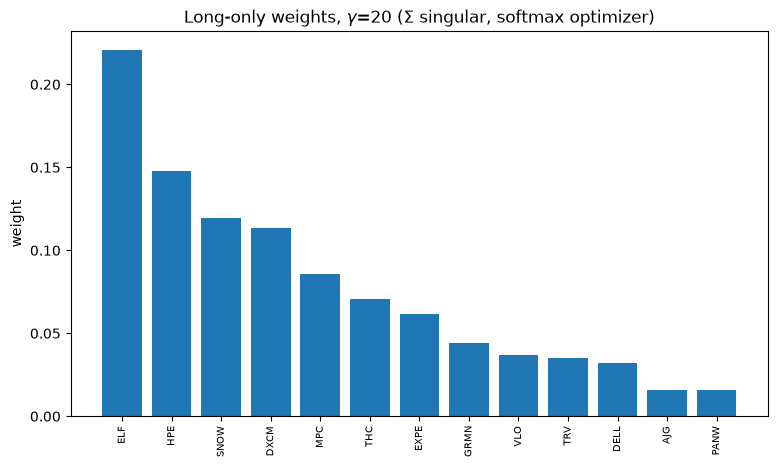

In [62]:
weights = pd.Series(w_long, index=tickers).sort_values(ascending=False)
nz = weights[weights > 1e-3]
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(range(len(nz)), nz.values)
ax.set_xticks(range(len(nz))); ax.set_xticklabels(nz.index, rotation=90, fontsize=7)
ax.set_ylabel("weight"); ax.set_title(rf"Long-only weights, $\gamma$={gamma:g} ($\Sigma$ singular, softmax optimizer)")


## Risk-aversion sweep

Higher $\gamma$ penalizes variance harder. Watch the **in-sample Sharpe inflate** as vol collapses — that's the optimizer exploiting the near-null-space directions where $w^\top\Sigma w$ is small (possible only because $\Sigma$ is singular). In-sample fantasy.


In [63]:
print(f"{'gamma':>6} {'holdings':>9} {'ann_ret%':>9} {'vol%':>7} {'Sharpe':>7}")
for g in [2, 10, 50, 200]:
    z = torch.zeros(N, dtype=torch.float64, requires_grad=True)
    opt = torch.optim.Adam([z], lr=0.5)
    for _ in range(8000):
        opt.zero_grad()
        w = torch.softmax(z, dim=0)
        loss = -(mu_t @ w - 0.5 * g * w @ Sig_t @ w)
        loss.backward()
        opt.step()
    w = torch.softmax(z, dim=0).detach().numpy()
    ar = w @ mu * 252
    av = np.sqrt(w @ Sigma @ w) * np.sqrt(252)
    print(f"{g:6d} {int((w > 1e-3).sum()):9d} {ar*100:9.1f} {av*100:7.1f} {ar/av:7.2f}")


 gamma  holdings  ann_ret%    vol%  Sharpe
     2         4     340.4    69.2    4.92
    10         7     267.2    34.2    7.82
    50        22     168.4    12.4   13.54
   200         6      84.1    10.4    8.07
